In [1]:
# Imports and Data Loading

# pandas: loads and manipulates our CSV data as a table (DataFrame)
# numpy: handles numerical array operations. TensorFlow outputs use it
# train_test_split: divides data into training and testing sets
# StandardScaler: normalizes features to the same scale (critical for ANNs)
# LabelEncoder: converts text labels (B/M) into numbers (0/1)
# classification_report: generates precision, recall, F1 automatically
# confusion_matrix: shows correct vs incorrect predictions in a grid
# matplotlib + seaborn: for plotting training curves and confusion matrix
# os: for creating folders to save our plots

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load and Inspect Data

data = pd.read_csv("breast_cancer_data.csv")

print("=== DATASET OVERVIEW ===")
print(f"Shape: {data.shape}")           # rows x columns
print(f"\nFirst 5 rows:\n{data.head()}")
print(f"\nData types:\n{data.dtypes}")

print("\n=== MISSING VALUES ===")
print(data.isnull().sum())

print("\n=== CLASS DISTRIBUTION ===")
print(data['y'].value_counts())
print(data['y'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


=== DATASET OVERVIEW ===
Shape: (569, 32)

First 5 rows:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810          

In [2]:
# Data Preprocessing

if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

# Separate features (X) from target label (y)
X = data.drop(columns=["y"])   # 30 numerical cell measurement features
y = data["y"]                  # Binary label: B = Benign, M = Malignant

# Encode target: B → 0, M → 1
# ANNs require numerical input, cannot process text labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(f"Encoded classes: {label_encoder.classes_} → [0, 1]")

# Split: 80% training, 20% testing
# stratify=y ensures both splits maintain the same B/M ratio
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features using StandardScaler
# ANNs are sensitive to feature scale: area_mean ranges 143–2501, while fractal_dim_mean ranges 0.05–0.16
# Without normalization, large scale features dominate learning
# fit_transform on train: learns mean and std FROM training data only
# transform on test: applies same scaling, never fit on test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n=== SPLIT SIZES ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Encoded classes: ['B' 'M'] → [0, 1]

=== SPLIT SIZES ===
X_train: (455, 30)
X_test:  (114, 30)
y_train: (455,)
y_test:  (114,)


In [5]:
# Build ANN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Set seed for reproducibility: ensures same results every run
tf.random.set_seed(42)

model = Sequential([

    # INPUT: explicitly defines 30 features entering the network
    Input(shape=(30,)),

    # FIRST HIDDEN LAYER
    # 16 neurons: sufficient capacity to detect patterns across 30 features
    # ReLU activation: outputs the value if positive, zero if negative
    # Most effective activation for hidden layers — avoids vanishing gradient problem
    Dense(16, activation='relu'),

    # DROPOUT LAYER: Model Improvement
    # Randomly deactivates 30% of neurons during each training step
    # Prevents overfitting: stops the model memorising training data
    Dropout(0.3),      
    Dense(8, activation='relu'),

    # OUTPUT LAYER
    # 1 neuron: outputs a single probability between 0 and 1
    # Sigmoid activation: squashes any value into (0,1) range
    # Above 0.5 = Malignant (1), at or below 0.5 = Benign (0)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training the Model

# EarlyStopping monitors validation loss during training
# patience=10: stops training if no improvement after 10 consecutive training rounds
# restore_best_weights: automatically reverts to the best performing version
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,           # maximum training rounds
    batch_size=16,        # number of samples processed before updating weights
    validation_split=0.2, # holds back 20% of training data to detect overfitting
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4808 - loss: 0.7346 - val_accuracy: 0.6923 - val_loss: 0.6275
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6621 - loss: 0.6056 - val_accuracy: 0.8681 - val_loss: 0.5199
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7967 - loss: 0.5064 - val_accuracy: 0.9231 - val_loss: 0.4482
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8516 - loss: 0.4544 - val_accuracy: 0.9341 - val_loss: 0.3860
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8791 - loss: 0.3887 - val_accuracy: 0.9341 - val_loss: 0.3317
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9011 - loss: 0.3374 - val_accuracy: 0.9341 - val_loss: 0.2843
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9176 - loss: 0.2952 - val_accuracy: 0.9451 - val_loss: 0.2450
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9341 - loss: 0.2517 - val_accuracy: 0.

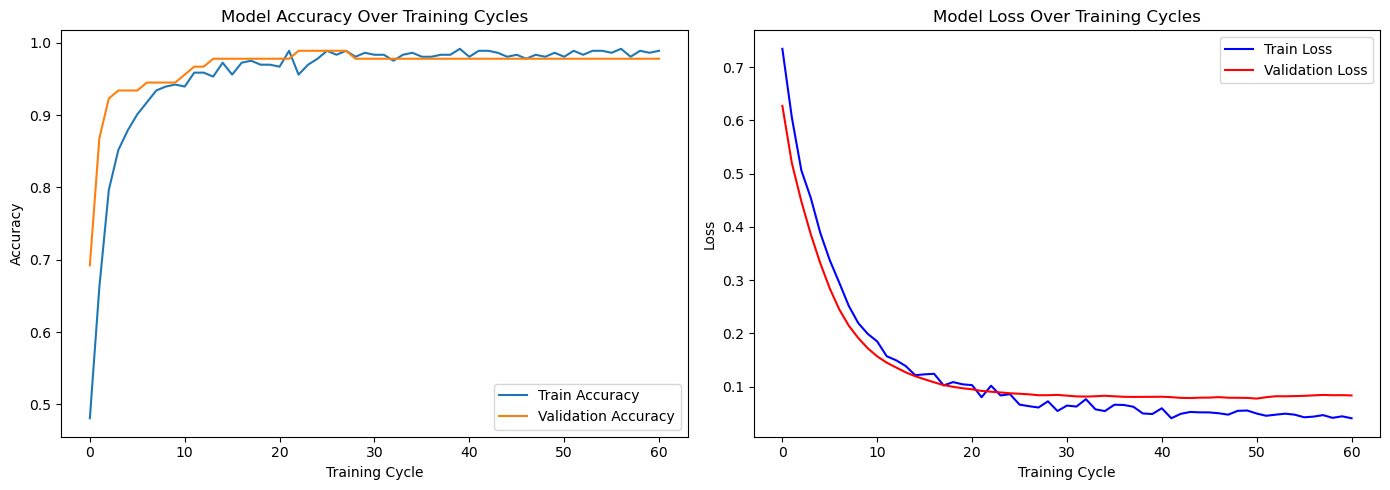

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

=== TEST RESULTS ===
Test Loss:     0.0586
Test Accuracy: 0.9825

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



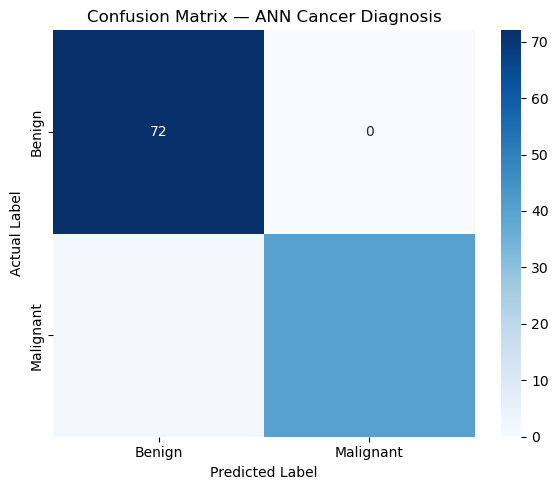

Model saved as cancer_ann_model.keras


In [10]:
# Plot Training Curves

import os
os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy: training vs validation
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy Over Training Cycles')
axes[0].set_xlabel('Training Cycle')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss: training vs validation
axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[1].set_title('Model Loss Over Training Cycles')
axes[1].set_xlabel('Training Cycle')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/training_curves.png", dpi=150)
plt.show()

# Evaluate the Model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
# model.predict returns raw probabilities between 0 and 1
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary: above 0.5 = Malignant (1), below = Benign (0)
y_pred = (y_pred_prob > 0.5).astype(int)

# Test loss and accuracy on unseen data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== TEST RESULTS ===")
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Full classification report
# Precision: of all Malignant predictions, how many were correct
# Recall: of all actual Malignant cases, how many did we catch
# F1-score: balance between precision and recall
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
      target_names=['Benign', 'Malignant']))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix — ANN Cancer Diagnosis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150)
plt.show()

# Save model
model.save("cancer_ann_model.keras")
print("Model saved as cancer_ann_model.keras")